In [1]:
''' econometrics is the branch of economics concerned with the use of mathematical methods'''
'''using this since we think there should be some correlations between different time series'''

'using this since we think there should be some correlations between different time series'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [3]:
from datetime import datetime

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [5]:
df = pd.read_excel('us_macro_quarterly.xlsx')

C:\Users\VARUN\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


# Data Preprocessing

In [6]:
df.head()

,Unnamed: 0,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL
0,1957:01,2851.778,8.414363,16.449,3.403333,3.390000,3.096667,3.933333,NaN,27.776667
1,1957:02,2845.453,9.097347,16.553,3.626667,3.540000,3.140000,4.100000,NaN,28.013333
2,1957:03,2873.169,9.042708,16.687,3.926667,3.963333,3.353333,4.233333,NaN,28.263333
3,1957:04,2843.718,8.796834,16.773,3.633333,3.586667,3.310000,4.933333,NaN,28.400000
4,1958:01,2770.000,8.632918,16.978,3.040000,2.160000,1.756667,6.300000,NaN,28.736667


In [7]:
''' year and quarter values '''

' year and quarter values '

In [8]:
def parse_date(data):
    year, quarter = data.split(':')
    month = (int(quarter) -1) * 3 + 1
    s = f'{year}-{month}'
    return datetime.strptime(s, '%Y-%m')

In [9]:
df['Date']= df['Unnamed: 0'].apply(parse_date)

In [10]:
df.head()

,Unnamed: 0,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL,Date
0,1957:01,2851.778,8.414363,16.449,3.403333,3.390000,3.096667,3.933333,NaN,27.776667,1957-01-01
1,1957:02,2845.453,9.097347,16.553,3.626667,3.540000,3.140000,4.100000,NaN,28.013333,1957-04-01
2,1957:03,2873.169,9.042708,16.687,3.926667,3.963333,3.353333,4.233333,NaN,28.263333,1957-07-01
3,1957:04,2843.718,8.796834,16.773,3.633333,3.586667,3.310000,4.933333,NaN,28.400000,1957-10-01
4,1958:01,2770.000,8.632918,16.978,3.040000,2.160000,1.756667,6.300000,NaN,28.736667,1958-01-01


In [11]:
df.shape

(228, 11)

In [12]:
df.set_index(df['Date'], inplace = True)
df.drop(['Date','Unnamed: 0'], axis = 1, inplace = True)

In [13]:

df.head()

,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL
Date,,,,,,,,,
1957-01-01,2851.778,8.414363,16.449,3.403333,3.390000,3.096667,3.933333,NaN,27.776667
1957-04-01,2845.453,9.097347,16.553,3.626667,3.540000,3.140000,4.100000,NaN,28.013333
1957-07-01,2873.169,9.042708,16.687,3.926667,3.963333,3.353333,4.233333,NaN,28.263333
1957-10-01,2843.718,8.796834,16.773,3.633333,3.586667,3.310000,4.933333,NaN,28.400000
1958-01-01,2770.000,8.632918,16.978,3.040000,2.160000,1.756667,6.300000,NaN,28.736667


In [14]:
df.index

DatetimeIndex(['1957-01-01', '1957-04-01', '1957-07-01', '1957-10-01',
               '1958-01-01', '1958-04-01', '1958-07-01', '1958-10-01',
               '1959-01-01', '1959-04-01',
               ...
               '2011-07-01', '2011-10-01', '2012-01-01', '2012-04-01',
               '2012-07-01', '2012-10-01', '2013-01-01', '2013-04-01',
               '2013-07-01', '2013-10-01'],
              dtype='datetime64[ns]', name='Date', length=228, freq=None)

In [15]:
df.index.freq = 'QS'

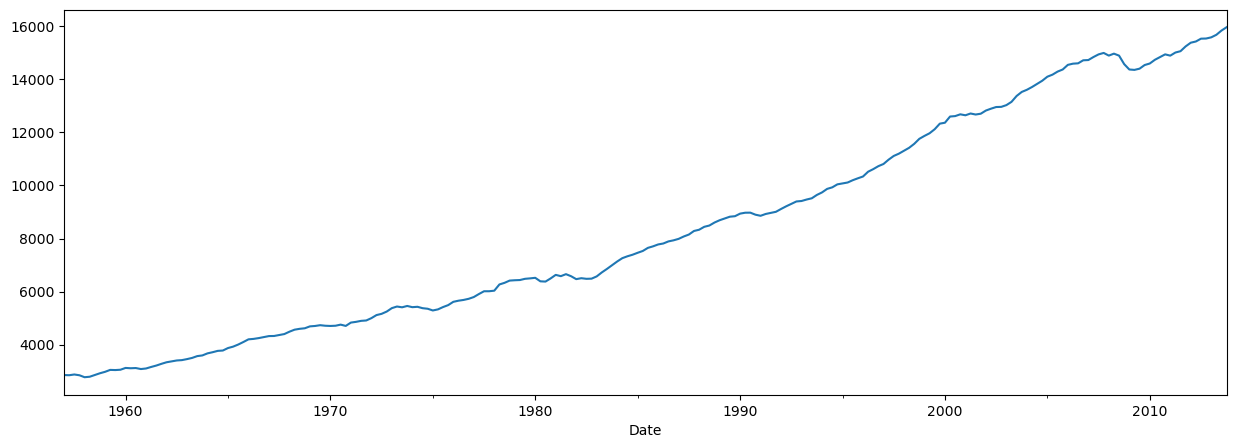

In [16]:
#GDP
df['GDPC96'].plot(figsize = (15,5));

In [17]:
df['GDPGrowth'] = np.log(df['GDPC96']).diff() # like log return

In [18]:
''' like log returns - using this since raw gdp is obviously not stationary and grp growth might be'''

' like log returns - using this since raw gdp is obviously not stationary and grp growth might be'

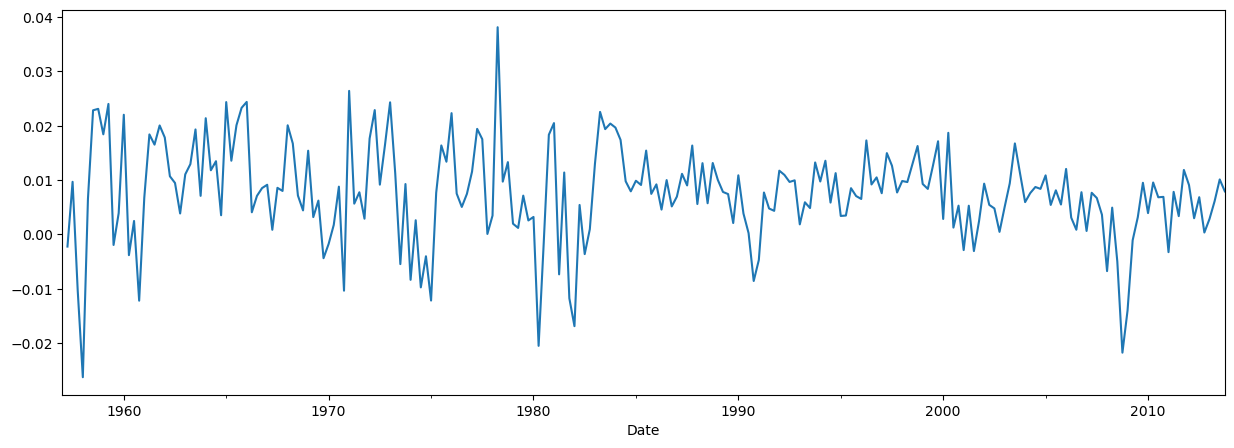

In [19]:
df['GDPGrowth'].plot(figsize =(15,5));

In [20]:
adfuller(df['GDPGrowth'].dropna())

(np.float64(-7.652127781838701),
 np.float64(1.777824221560178e-11),
 1,
 225,
 {'1%': np.float64(-3.4597521044060353),
  '5%': np.float64(-2.874472927517147),
  '10%': np.float64(-2.5736628197530864)},
 np.float64(-1449.0839103632056))

In [21]:
df['TSpread'] = df['GS10'] - df['TB3MS']
# term spread is the diff between long term rate and short term rate

In [22]:
''' long term rate should be greater than short term rates since more reward for long term investments'''

' long term rate should be greater than short term rates since more reward for long term investments'

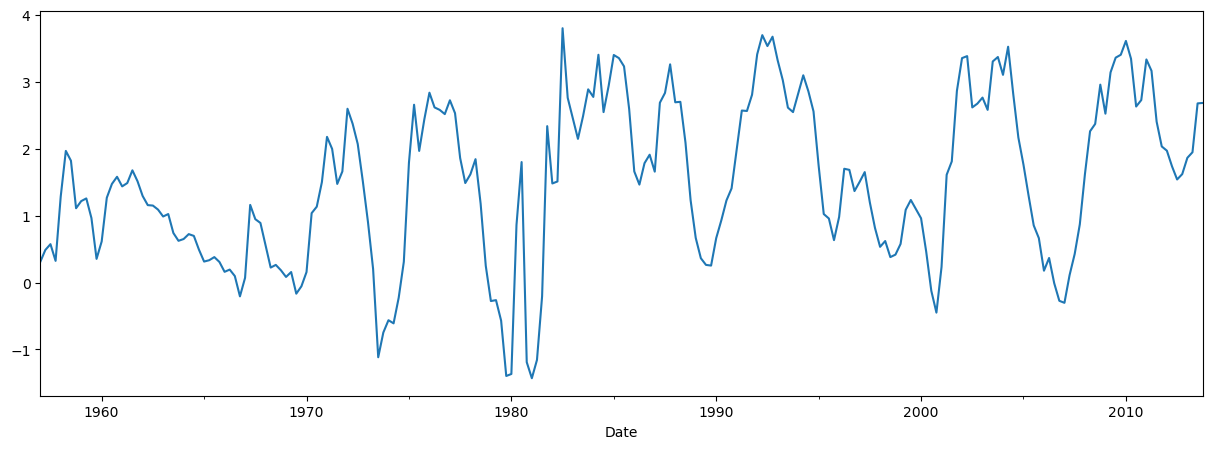

In [23]:
df['TSpread'].plot(figsize =(15,5));

In [24]:
''' having this term spread since this could be impacting the 'GDPGrowth'.
 some sort of cyclical pattern'''

" having this term spread since this could be impacting the 'GDPGrowth'.\n some sort of cyclical pattern"

In [25]:
adfuller(df['TSpread'])

(np.float64(-4.651668678966205),
 np.float64(0.00010362166028565551),
 9,
 218,
 {'1%': np.float64(-3.460707667106296),
  '5%': np.float64(-2.874891213486339),
  '10%': np.float64(-2.573885987711472)},
 np.float64(335.8880444855573))

In [26]:
cols = ['GDPGrowth','TSpread']

In [27]:
df1 = df.iloc[1:][cols].copy() # since 1st row of the log growth rate is nan

# Granger Causality test

In [29]:
'''### the null hypothesis of granger causality test is that the time series in 2nd column , does NOT granger causes the time series in the first
###column. 
Granger causality means that the past values of 2nd column have statistically significant effect on the current value of 1st time series, 
# taking past values of x1 into account as predictors for the 1st column'''

'### the null hypothesis of granger causality test is that the time series in 2nd column , does NOT granger causes the time series in the first\n###column. \nGranger causality means that the past values of 2nd column have statistically significant effect on the current value of 1st time series, \n# taking past values of x1 into account as predictors for the 1st column'

In [31]:
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

In [34]:
df1.head(n=2)

,GDPGrowth,TSpread
Date,,
1957-04-01,-0.002220,0.486667
1957-07-01,0.009693,0.573333


In [36]:
''' since the 2nd value is TSspread, we check whether time series TSpread granges causes the time series GDPGrowth and not the other way round'''

' since the 2nd value is TSspread, we check whether time series TSpread granges causes the time series GDPGrowth and not the other way round'

In [38]:
granger_result = grangercausalitytests(df1, maxlag=18) # using maxlags 18 since this is what we used in the varmax below


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.1781  , p=0.0137  , df_denom=223, df_num=1
ssr based chi2 test:   chi2=6.2612  , p=0.0123  , df=1
likelihood ratio test: chi2=6.1761  , p=0.0129  , df=1
parameter F test:         F=6.1781  , p=0.0137  , df_denom=223, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.9160  , p=0.0082  , df_denom=220, df_num=2
ssr based chi2 test:   chi2=10.0555 , p=0.0066  , df=2
likelihood ratio test: chi2=9.8373  , p=0.0073  , df=2
parameter F test:         F=4.9160  , p=0.0082  , df_denom=220, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4458  , p=0.0176  , df_denom=217, df_num=3
ssr based chi2 test:   chi2=10.6710 , p=0.0136  , df=3
likelihood ratio test: chi2=10.4246 , p=0.0153  , df=3
parameter F test:         F=3.4458  , p=0.0176  , df_denom=217, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.8964  , p=0.0230  

In [40]:
''' say, we set the significance threshold to 5% (0.05), any pvalue less than 5% makes that lag statistically significant'''

' say, we set the significance threshold to 5% (0.05), any pvalue less than 5% makes that lag statistically significant'

In [41]:
'''for lag values >=12, siginificance tests not passed since p values much higher than 5% threshold'''

'for lag values >=12, siginificance tests not passed since p values much higher than 5% threshold'

In [47]:
# ''' testing if gdp growth can forecast the term spread'''
granger_result = grangercausalitytests(df1[reversed(cols)], maxlag=18)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=11.9872 , p=0.0006  , df_denom=223, df_num=1
ssr based chi2 test:   chi2=12.1485 , p=0.0005  , df=1
likelihood ratio test: chi2=11.8332 , p=0.0006  , df=1
parameter F test:         F=11.9872 , p=0.0006  , df_denom=223, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.4010  , p=0.0051  , df_denom=220, df_num=2
ssr based chi2 test:   chi2=11.0476 , p=0.0040  , df=2
likelihood ratio test: chi2=10.7849 , p=0.0046  , df=2
parameter F test:         F=5.4010  , p=0.0051  , df_denom=220, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.8793  , p=0.0026  , df_denom=217, df_num=3
ssr based chi2 test:   chi2=15.1100 , p=0.0017  , df=3
likelihood ratio test: chi2=14.6221 , p=0.0022  , df=3
parameter F test:         F=4.8793  , p=0.0026  , df_denom=217, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.1513  , p=0.0152  

In [48]:
''' very significant p values for all lags.
just means GDPGrwoth has higher forecasting power to forecast TSpread for more lags compared to the other way round 
'''

' very significant p values for all lags.\njust means GDPGrwoth has higher forecasting power to forecast TSpread for more lags compared to the other way round \n'

In [50]:
Ntest = 12
train = df1.iloc[:-Ntest].copy()
test = df1.iloc[-Ntest:].copy()

In [51]:
train_idx = df1.index<=train.index[-1]
test_idx = df1.index>train.index[-1] # we could have also done test_idx = ~ train_idx

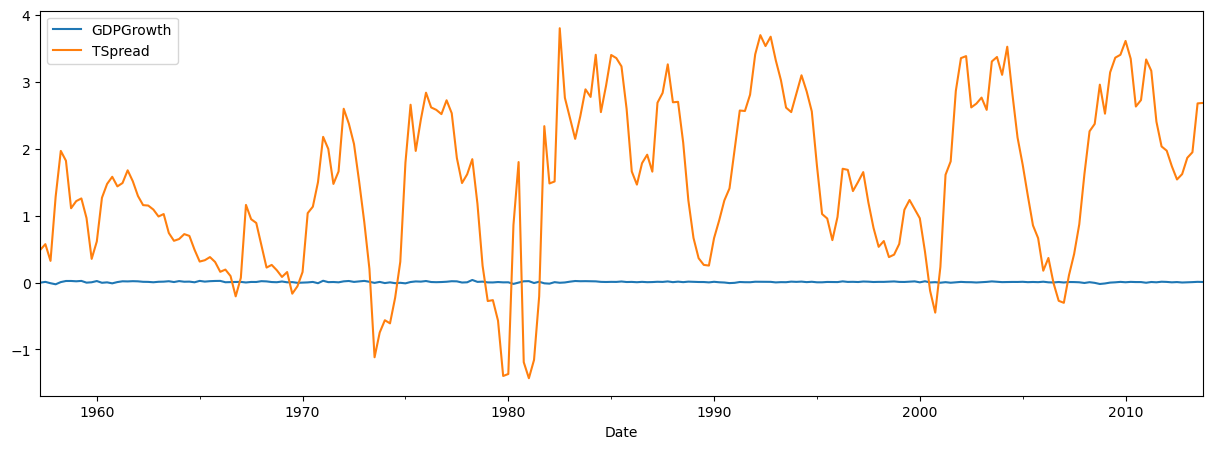

In [52]:
df1[cols].plot(figsize = (15,5));

In [53]:
''' need to bring both in the same scale'''

' need to bring both in the same scale'

In [54]:
''' overwriting the originals - dont want to preserve them'''
scaler = StandardScaler()
train[cols]= scaler.fit_transform(train)
test[cols]= scaler.transform(test)

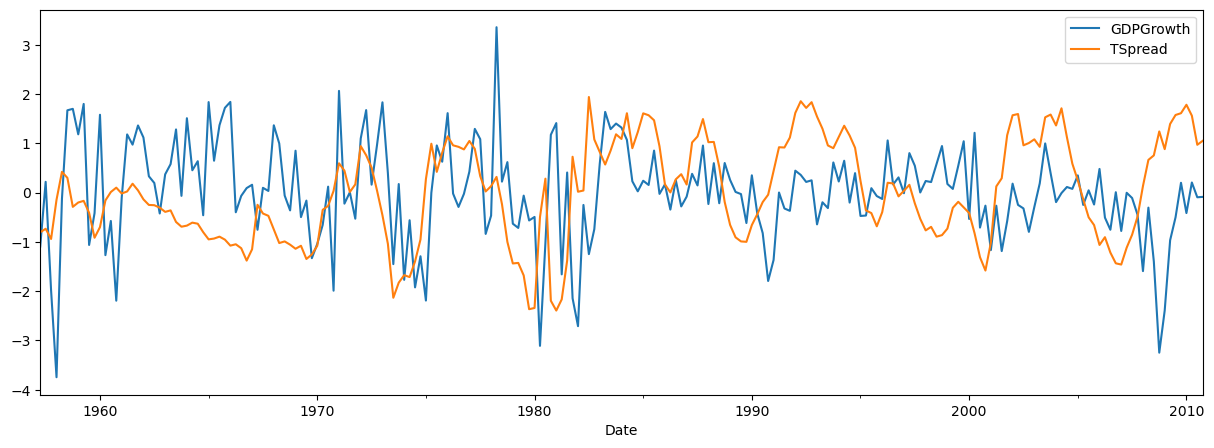

In [55]:
train[cols].plot(figsize = (15,5));

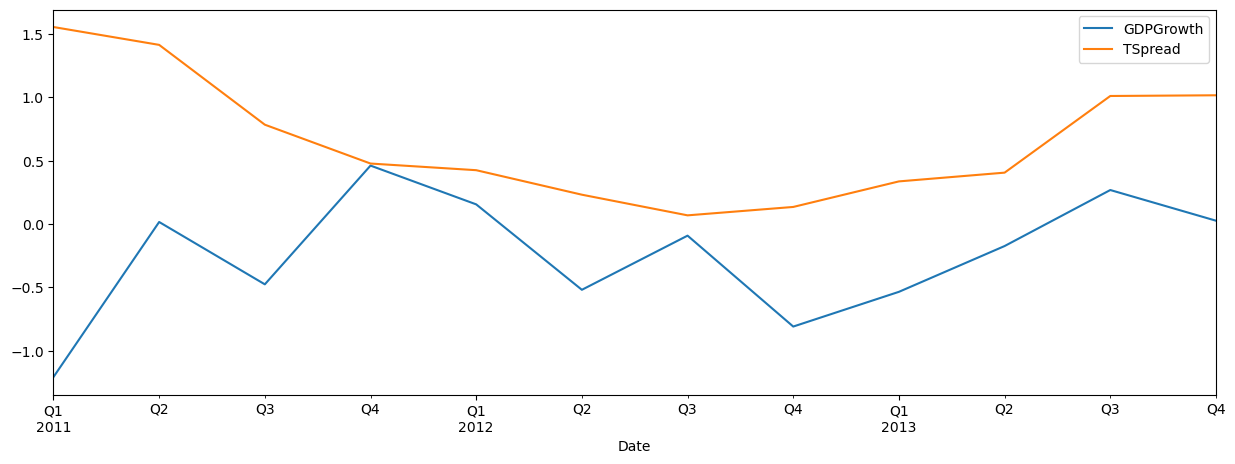

In [56]:
test[cols].plot(figsize = (15,5));

In [57]:
df1.loc[train_idx, :] = train
df1.loc[test_idx,:] = test

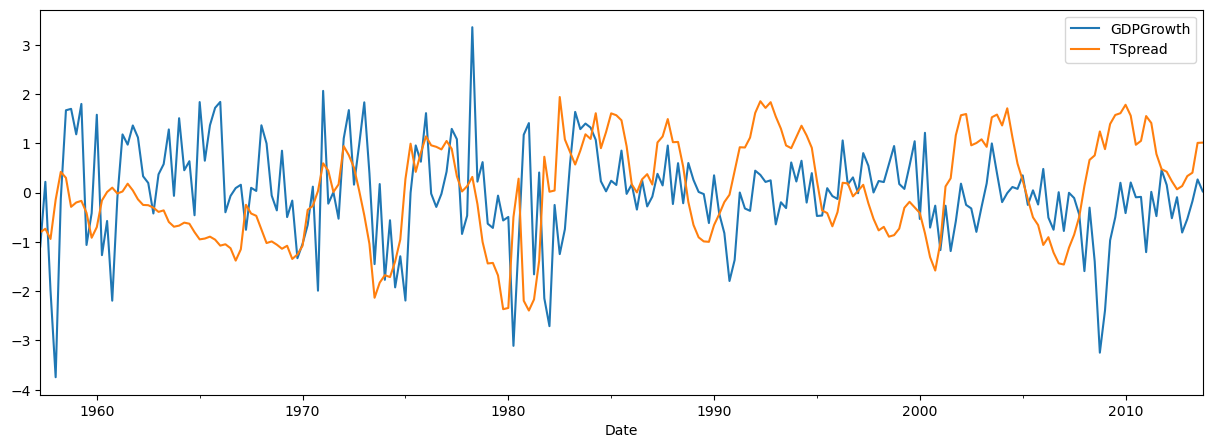

In [58]:
df1[cols].plot(figsize = (15,5));

In [59]:
cols

['GDPGrowth', 'TSpread']

In [72]:
adfuller(train['GDPGrowth'])

(np.float64(-7.446639654625579),
 np.float64(5.8148965809139116e-11),
 1,
 213,
 {'1%': np.float64(-3.461429147102264),
  '5%': np.float64(-2.875206950587861),
  '10%': np.float64(-2.5740544497344002)},
 np.float64(512.854231063742))

In [73]:
adfuller(train['TSpread'])

(np.float64(-4.001020795475581),
 np.float64(0.001405175490749354),
 12,
 202,
 {'1%': np.float64(-3.4631437906252636),
  '5%': np.float64(-2.8759570379821047),
  '10%': np.float64(-2.574454682874228)},
 np.float64(246.36949884218734))

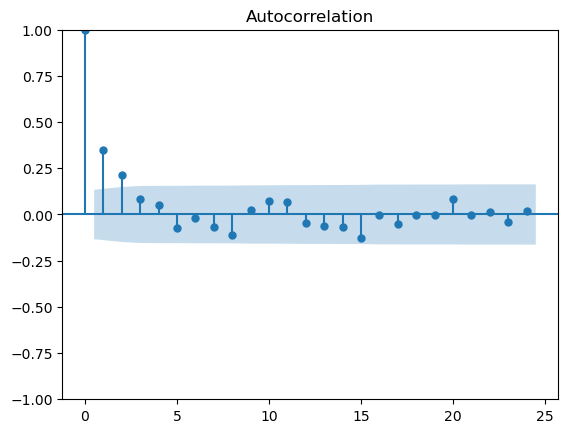

In [62]:
plot_acf(train['GDPGrowth']);

In [65]:
'''acf seems small q value, BUT NOTE THAT THEY ARE NOT EXACT Q TERMS to be used in VARMA since the above doesnt 
consider cross feature (diff time series) impact.
BETTER TO DO A GRIDSEARCH TO FIND THE BEST MODEL
'''

'acf seems small q value, BUT NOTE THAT THEY ARE NOT EXACT Q TERMS to be used in VARMA since the above doesnt \nconsider cross feature (diff time series) impact.\nBETTER TO DO A GRIDSEARCH TO FIND THE BEST MODEL\n'

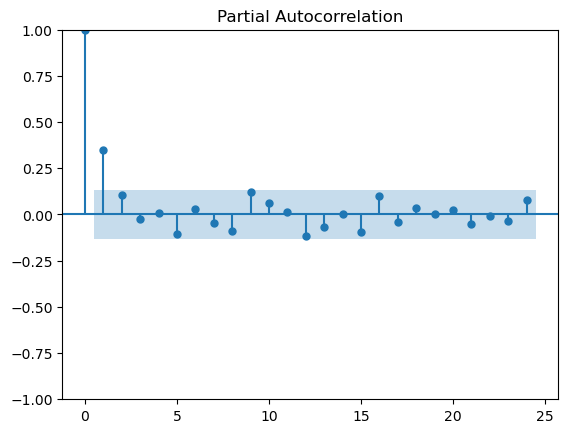

In [66]:
plot_pacf(train['GDPGrowth']);

In [67]:
''' small p value suggested'''

' small p value suggested'

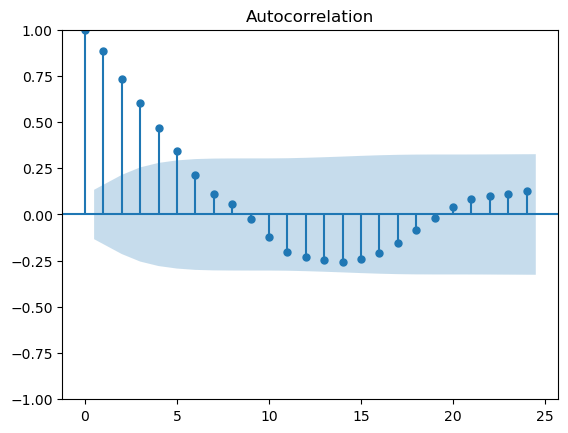

In [68]:
plot_acf(train['TSpread']);

In [69]:
''' suggests tspread being cylical in nature as observed in the graph as well'''

' suggests tspread being cylical in nature as observed in the graph as well'

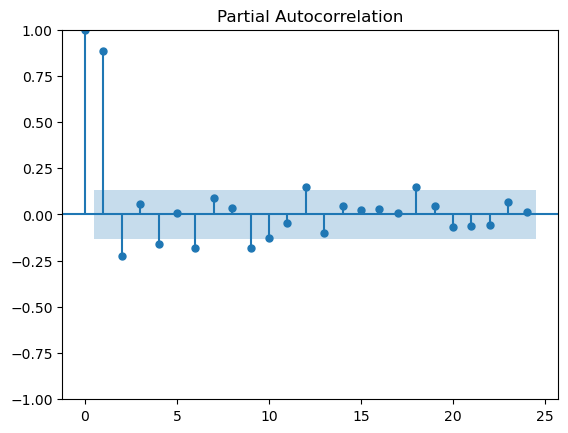

In [70]:
plot_pacf(train['TSpread']);

In [71]:
'''higher p value suggested although significantly higher pacf in smaller lags only'''

'higher p value suggested although significantly higher pacf in smaller lags only'

# VARMAX

In [75]:
p = 18 # higher value selected looking at pacf of TSpread suggested a larger p
q = 1
'''choosen arbitrarily'''

'choosen arbitrarily'

In [76]:
train.head()

,GDPGrowth,TSpread
Date,,
1957-04-01,-1.094132,-0.804627
1957-07-01,0.219378,-0.732834
1957-10-01,-1.985286,-0.939930
1958-01-01,-3.745106,-0.144679
1958-04-01,-0.124216,0.421386


In [77]:
t0 = datetime.now()
model = VARMAX(train, order =(p,q))
res = model.fit(maxiter = 100)
print("Duration",datetime.now() - t0)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Duration 0:00:59.051750


In [79]:
''' had explained earlier why it fails to converge since - num of parameters become 2(18*(2^2) + 2) = 148, and also maxiter is small.
hence we say VAR is better and more widely used.
and also the problem os VARMAX having identifiability issues since more than one solution possible'''

' had explained earlier why it fails to converge since - num of parameters become 2(18*(2^2) + 2) = 148, and also maxiter is small.\nhence we say VAR is better and more widely used.\nand also the problem os VARMAX having identifiability issues since more than one solution possible'

In [80]:
fcast = res.get_forecast(Ntest)

In [82]:
fcast.predicted_mean

,GDPGrowth,TSpread
2011-01-01,-0.325128,0.952519
2011-04-01,-0.460814,1.173604
2011-07-01,-1.086305,1.167375
2011-10-01,-0.134553,1.117991
2012-01-01,-0.057008,0.720129
2012-04-01,-0.065998,0.406222
2012-07-01,-0.076362,0.379186
2012-10-01,-0.326248,0.207782
2013-01-01,-0.377902,-0.088975
2013-04-01,-0.266183,0.058523


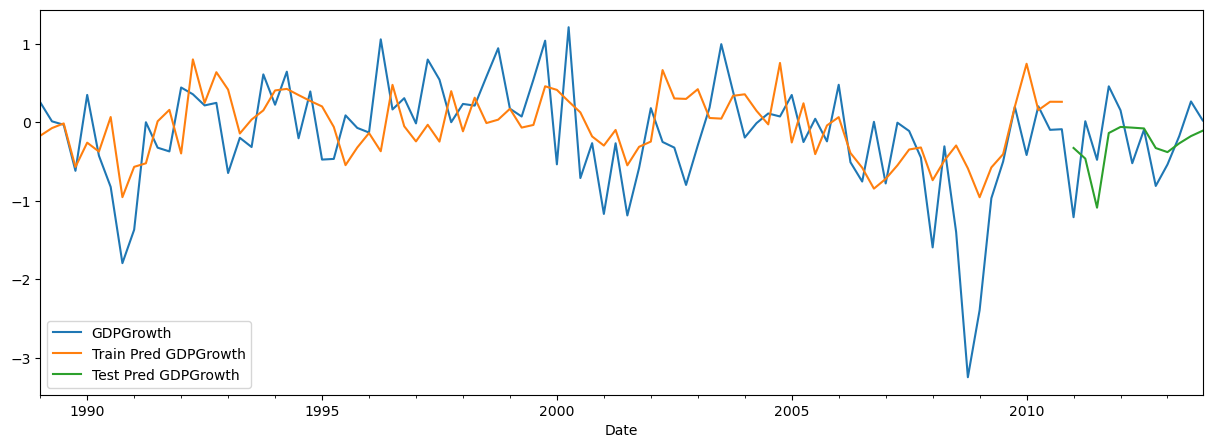

In [83]:
df1.loc[train_idx, 'Train Pred GDPGrowth'] = res.fittedvalues['GDPGrowth']
df1.loc[test_idx, 'Test Pred GDPGrowth'] = fcast.predicted_mean['GDPGrowth']

plot_cols = ['GDPGrowth','Train Pred GDPGrowth','Test Pred GDPGrowth']
df1.iloc[-100:][plot_cols].plot(figsize = (15,5));

In [88]:
''' not quite good specially during extremes. However. prediction does seem to go in the same direction as the true value'''

' not quite good specially during extremes. However. prediction does seem to go in the same direction as the true value'

In [89]:
''' to check if its good enough is by comparing it with NAIVE FORECAST'''

' to check if its good enough is by comparing it with NAIVE FORECAST'

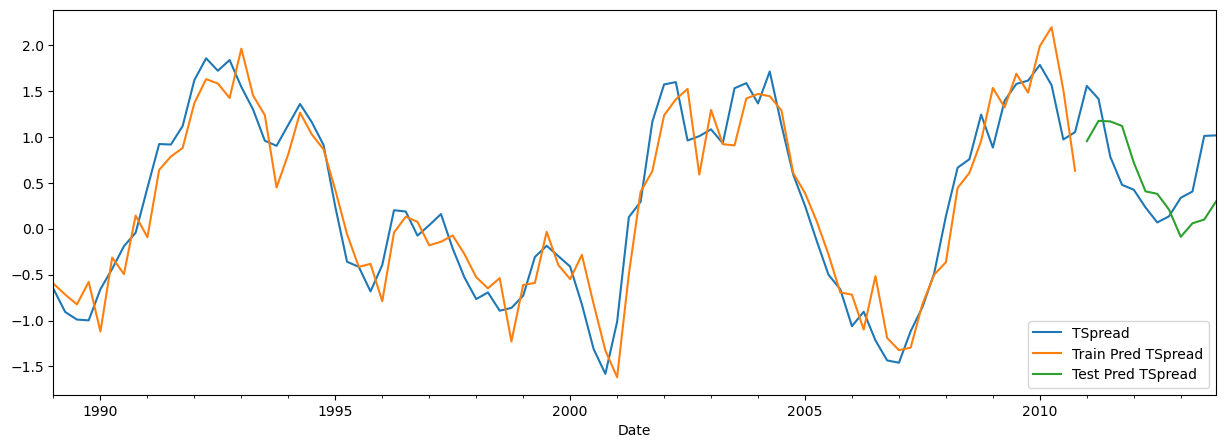

In [92]:
df1.loc[train_idx, 'Train Pred TSpread'] = res.fittedvalues['TSpread']
df1.loc[test_idx, 'Test Pred TSpread'] = fcast.predicted_mean['TSpread']

plot_cols = ['TSpread','Train Pred TSpread','Test Pred TSpread']
df1.iloc[-100:][plot_cols].plot(figsize = (15,5)); 

In [93]:
'''train predictions pretty goog but seem to be lagging by 1 step - typically happens when we have trend with noise.

TEST PRED SEEMS TO BE LAGGING BY 1 STEP BUT THIS IS NOT THE CASE SINCE MODEL HASNT SEEN THE TEST SET DATA . MODEL REALLY IS 
FORECASTING THE CURVE ONLY HAVING SEEN THE TRAIN SET. GOOD THAT ITS ABLE TO CAPTURE THE TREND'''

'train predictions pretty goog but seem to be lagging by 1 step - typically happens when we have trend with noise.\n\nTEST PRED SEEMS TO BE LAGGING BY 1 STEP BUT THIS IS NOT THE CASE SINCE MODEL HASNT SEEN THE TEST SET DATA . MODEL REALLY IS \nFORECASTING THE CURVE ONLY HAVING SEEN THE TRAIN SET. GOOD THAT ITS ABLE TO CAPTURE THE TREND'

In [95]:
cols

['GDPGrowth', 'TSpread']

In [98]:
for col in cols:
    y_true = df1.loc[train_idx, col]
    y_pred = res.fittedvalues[col]
    print(f"train r^2 {col}:", r2_score(y_true, y_pred))

    y_true = df1.loc[test_idx, col]
    y_pred = fcast.predicted_mean[col]
    print(f"test r^2: {col}", r2_score(y_true, y_pred))

train r^2 GDPGrowth: 0.2763815377229175
test r^2: GDPGrowth 0.033919611975238184
train r^2 TSpread: 0.8737086875969485
test r^2: TSpread -0.054381782654201904


In [99]:
'''this is pretty low as seen in the plots too'''
''' however, for gdpgrowth the test score is better than predicting the average test value'''
''' for tsspread, train score higher since its lagging, and also the acf plot of tsspread showed very high correlation with lagged values'''

' for tsspread, train score higher since its lagging, and also the acf plot of tsspread showed very high correlation with lagged values'

# VAR

In [100]:
model = VAR(train)

In [102]:
lag_order_results = model.select_order(maxlags=20)
lag_order_results.selected_orders

{'aic': np.int64(10),
 'bic': np.int64(1),
 'hqic': np.int64(2),
 'fpe': np.int64(10)}

In [105]:
'''aic showing best resullts in lag order 10, which is 2.5 years'''

'aic showing best resullts in lag order 10, which is 2.5 years'

In [106]:
results = model.fit(maxlags = 20, ic = 'aic')

In [107]:
lag_order  = results.k_ar

In [110]:
lag_order

10

In [111]:
prior = train.iloc[-lag_order:][cols].to_numpy()
fcast = results.forecast(prior, Ntest)

In [113]:
results.fittedvalues

,GDPGrowth,TSpread
Date,,
1959-10-01,-0.044643,-0.660157
1960-01-01,-0.135105,-0.997066
1960-04-01,-0.275847,-0.143562
1960-07-01,-1.079816,0.050886
1960-10-01,-0.342139,0.260718
...,...,...
2009-10-01,0.041761,1.419885
2010-01-01,0.349611,2.043212
2010-04-01,-0.118981,1.960557


In [112]:
fcast

array([[-0.47795915,  1.06175102],
       [-0.55087395,  1.2089578 ],
       [-0.62043237,  1.40377678],
       [-0.31903969,  1.31743919],
       [ 0.04677131,  1.22341711],
       [-0.07510771,  1.07269729],
       [ 0.05955826,  0.81966323],
       [ 0.08820515,  0.6132845 ],
       [ 0.12636779,  0.467321  ],
       [ 0.05983734,  0.33590818],
       [-0.04163351,  0.31443787],
       [-0.19874455,  0.31626073]])

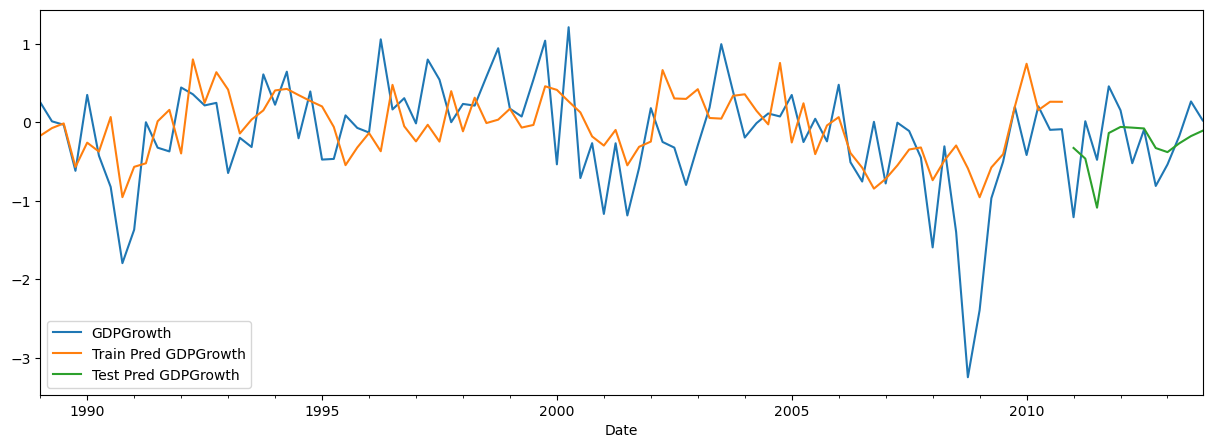

In [120]:
df1.loc[train_idx , 'Train Pred GDP Growth'] = results.fittedvalues['GDPGrowth']
df1.loc[test_idx , 'Test Pred GDP Growth'] = fcast[:,0]

plot_cols = ['GDPGrowth','Train Pred GDPGrowth','Test Pred GDPGrowth']
df1.iloc[-100:][plot_cols].plot(figsize = (15,5));

In [121]:
'''cant tell by just looking if this is better or worse than the VARMAX model'''

'cant tell by just looking if this is better or worse than the VARMAX model'

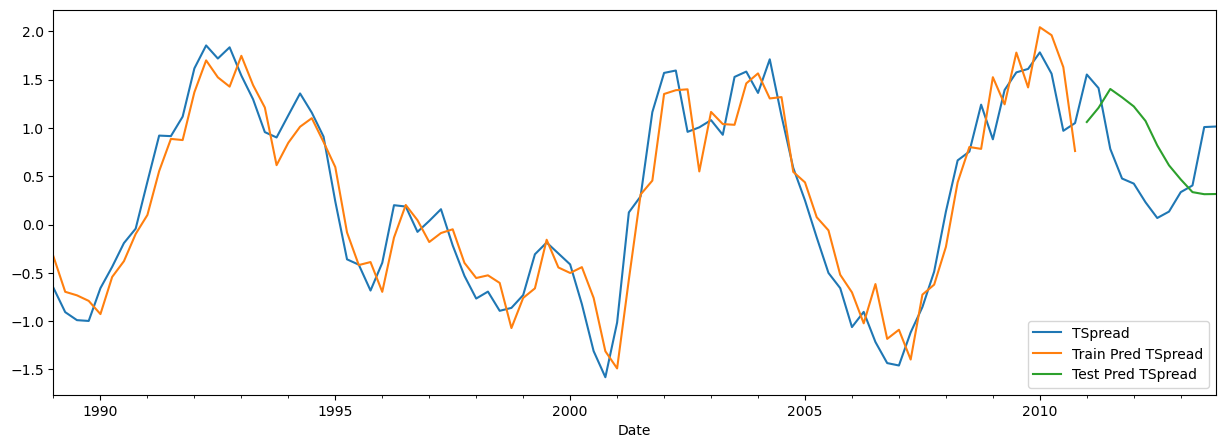

In [122]:
df1.loc[train_idx , 'Train Pred TSpread'] = results.fittedvalues['TSpread']
df1.loc[test_idx , 'Test Pred TSpread'] = fcast[:,1]

plot_cols = ['TSpread','Train Pred TSpread','Test Pred TSpread']
df1.iloc[-100:][plot_cols].plot(figsize = (15,5));

In [124]:
''' test predictions are much worse than VARMAX'''
''' insample lags previous values'''

' insample lags previous values'

In [128]:
cols

['GDPGrowth', 'TSpread']

In [129]:
for i, col in enumerate(cols):
    print(i," - ", col)

0  -  GDPGrowth
1  -  TSpread


In [139]:
for i,col in enumerate(cols):
    y_true = df1.loc[train_idx, col]
    y_pred = results.fittedvalues[col]
    y_true = y_true.iloc[lag_order:] # doing this since vAR is not a statespace model like varmax and 1st lag_order rows will be nan
    # y_pred = y_pred[lag_order:] # this is already of smaller rows
    print(f"train r^2 {col}:", r2_score(y_true, y_pred))

    y_true = df1.loc[test_idx, col]
    y_pred = fcast[:,i]
    print(f"test r^2: {col}", r2_score(y_true, y_pred))

train r^2 GDPGrowth: 0.2569812409739456
test r^2: GDPGrowth -0.2396176056726118
train r^2 TSpread: 0.8581031996649263
test r^2: TSpread -0.6717328659710928


In [140]:
''' train and test both worse than varimax '''

' train and test both worse than varimax '

# ARIMA Baseline

In [141]:
print(p)
print(q)

18
1


In [144]:
for col in cols:
    model = ARIMA(train[col], order =(p,0,q)) # using p and q same as that of varimax
    res = model.fit()
    fcast = res.get_forecast(Ntest)
    y_train = df1.loc[train_idx, col]
    y_test = df1.loc[test_idx, col]
    print(f'{col} Train R^2:', r2_score(y_train, res.fittedvalues))
    print(f'{col} Test R^2:', r2_score(y_test, fcast.predicted_mean))

GDPGrowth Train R^2: 0.20569396886526348
GDPGrowth Test R^2: -0.8486463896899954
TSpread Train R^2: 0.8332486531720475
TSpread Test R^2: -2.9963834713578863


In [145]:
'''ARIMA is worse '''

'ARIMA is worse '

# conclusion
## VARMAX seems to be better in this case